Dataset Shape: (319, 8)
                     Company Name  Listing Date  Issue Price (Rs)  \
0           Innova Captab Limited  Dec 29, 2023               448   
1        Azad Engineering Limited  Dec 28, 2023               524   
2           RBZ Jewellers Limited  Dec 27, 2023               100   
3  Credo Brands Marketing Limited  Dec 27, 2023               280   
4          Happy Forgings Limited  Dec 27, 2023               850   

   Listing Day - Close Price (Rs)  Listing Day Gain / Loss (%)  \
0                          545.15                        21.69   
1                          677.10                        29.22   
2                          104.99                         4.99   
3                          312.50                        11.61   
4                         1029.80                        21.15   

   Current Price at BSE (Rs)  Current Price at NSE (Rs)  Gain / Loss (%)  
0                     658.25                     657.90            46.93  
1             

/tmp/ipykernel_379/369145618.py:75: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download("^NSEI", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed



Market Data Preview
Price Listing Date         Open        Close  Market_Sentiment
0       2015-01-02  8288.700195  8395.450195                 1
1       2015-01-05  8407.950195  8378.400391                 0
2       2015-01-06  8325.299805  8127.350098                 0
3       2015-01-07  8118.649902  8102.100098                 0
4       2015-01-08  8191.399902  8234.599609                 1

Dataset after merge: (277, 10)

Cluster Distribution
Cluster
1    116
2    108
0     53
Name: count, dtype: int64


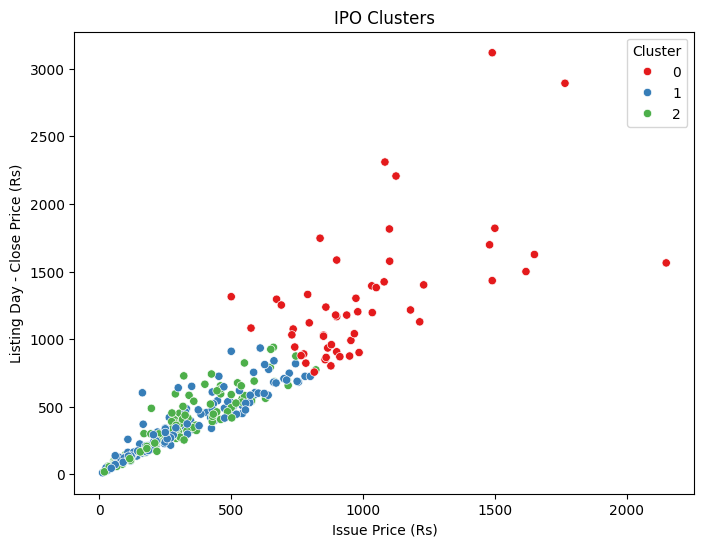


Training Samples: 221
Testing Samples: 56

Model Accuracy
Logistic Regression: 0.8035714285714286
Decision Tree: 0.8035714285714286
Random Forest: 0.8035714285714286


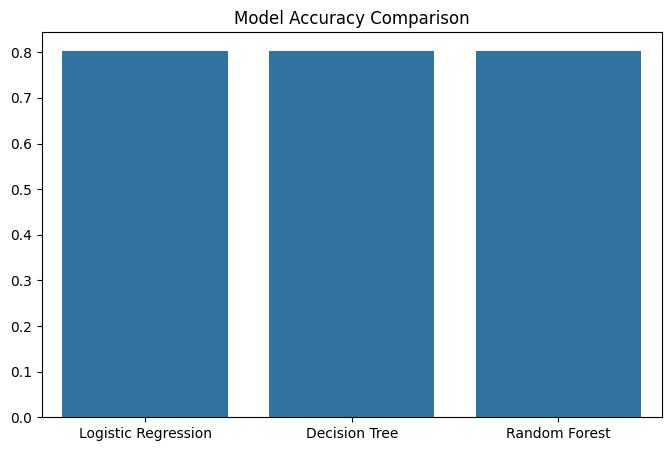

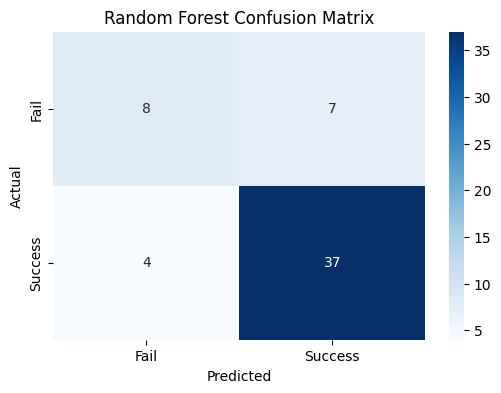


Classification Report
              precision    recall  f1-score   support

           0       0.67      0.53      0.59        15
           1       0.84      0.90      0.87        41

    accuracy                           0.80        56
   macro avg       0.75      0.72      0.73        56
weighted avg       0.79      0.80      0.80        56



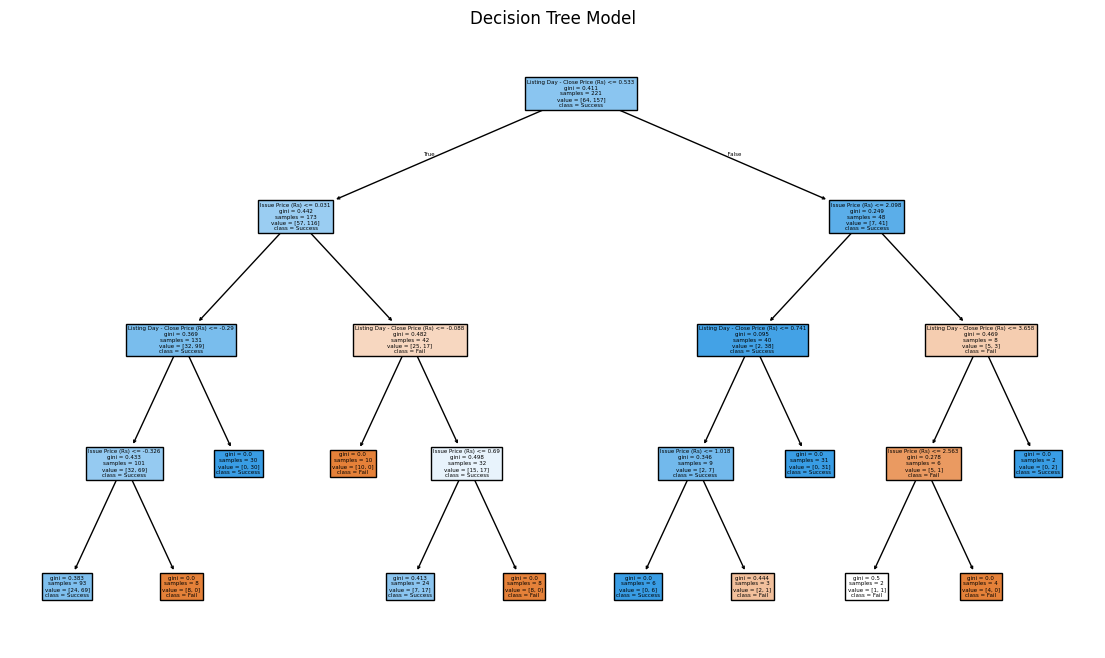

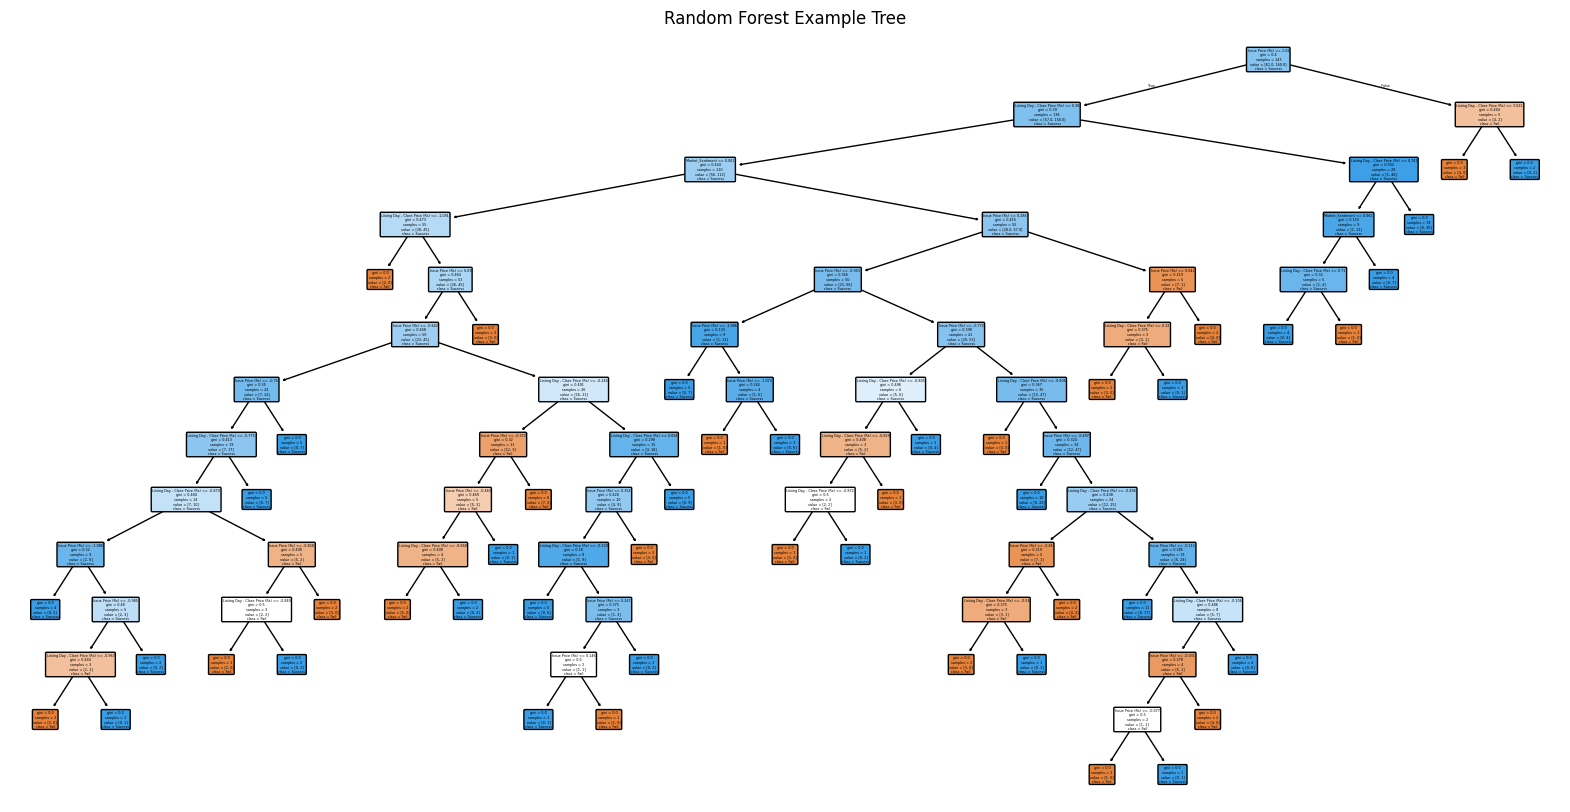

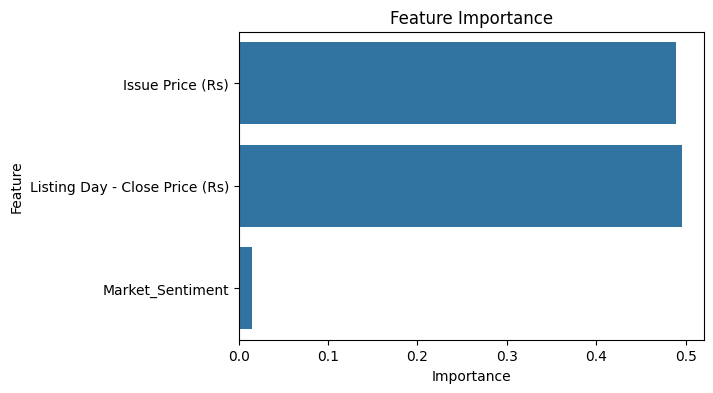


Enter IPO Details
Issue Price (Rs): 200
Expected Listing Price (Rs): 225
Market Sentiment (1 = Green Market, 0 = Red Market): 1

Prediction: IPO likely SUCCESSFUL
Success Probability: 0.91


In [ ]:
# ==========================================
# INSTALL REQUIRED LIBRARIES
# ==========================================

!pip install yfinance

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("ipo_dataset.csv")

# Clean column names
df.columns = df.columns.str.replace("\n"," ")

print("Dataset Shape:", df.shape)
print(df.head())


# ==========================================
# DATA CLEANING
# ==========================================

df["Listing Date"] = pd.to_datetime(df["Listing Date"])

df["Issue Price (Rs)"] = pd.to_numeric(df["Issue Price (Rs)"], errors="coerce")

df["Listing Day - Close Price (Rs)"] = pd.to_numeric(
    df["Listing Day - Close Price (Rs)"], errors="coerce"
)

df["Listing Day Gain / Loss (%)"] = pd.to_numeric(
    df["Listing Day Gain / Loss (%)"], errors="coerce"
)

df = df.dropna()


# ==========================================
# CREATE TARGET VARIABLE
# ==========================================

df["IPO_Success"] = np.where(df["Listing Day Gain / Loss (%)"] > 0, 1, 0)

print("\nIPO Success Distribution")
print(df["IPO_Success"].value_counts())


# ==========================================
# DOWNLOAD NIFTY MARKET DATA
# ==========================================

nifty = yf.download("^NSEI", start="2015-01-01", end="2024-12-31")

# Fix MultiIndex columns
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

# Select only needed columns
nifty = nifty[["Open","Close"]]

# Create sentiment variable
nifty["Market_Sentiment"] = (nifty["Close"] > nifty["Open"]).astype(int)

# Convert index to column
nifty.reset_index(inplace=True)

# Rename date column
nifty.rename(columns={"Date":"Listing Date"}, inplace=True)

print("\nMarket Data Preview")
print(nifty.head())


# ==========================================
# MERGE MARKET DATA WITH IPO DATA
# ==========================================

df["Listing Date"] = pd.to_datetime(df["Listing Date"])
nifty["Listing Date"] = pd.to_datetime(nifty["Listing Date"])

df = pd.merge(
    df,
    nifty[["Listing Date","Market_Sentiment"]],
    on="Listing Date",
    how="left"
)

df = df.dropna()

print("\nDataset after merge:", df.shape)


# FEATURE SELECTION


features = [
    "Issue Price (Rs)",
    "Listing Day - Close Price (Rs)",
    "Market_Sentiment"
]

X = df[features]

y = df["IPO_Success"]


# FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# KMEANS CLUSTERING

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Distribution")
print(df["Cluster"].value_counts())

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Issue Price (Rs)"],
    y=df["Listing Day - Close Price (Rs)"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("IPO Clusters")

plt.show()


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# TRAIN MACHINE LEARNING MODELS

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)


# Decision Tree
tree_model = DecisionTreeClassifier(max_depth=4)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)


# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)


# MODEL PERFORMANCE


print("\nModel Accuracy")

print("Logistic Regression:", log_acc)
print("Decision Tree:", tree_acc)
print("Random Forest:", rf_acc)


models = ["Logistic Regression","Decision Tree","Random Forest"]
scores = [log_acc, tree_acc, rf_acc]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.title("Model Accuracy Comparison")

plt.show()


# CONFUSION MATRIX

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail","Success"],
    yticklabels=["Fail","Success"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

print("\nClassification Report")
print(classification_report(y_test, rf_pred))


# DECISION TREE VISUALIZATION


plt.figure(figsize=(14,8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Fail","Success"],
    filled=True
)

plt.title("Decision Tree Model")

plt.show()


# RANDOM FOREST TREE VISUALIZATION


rf_tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))

plot_tree(
    rf_tree,
    feature_names=features,
    class_names=["Fail","Success"],
    filled=True,
    rounded=True
)

plt.title("Random Forest Example Tree")

plt.show()


# FEATURE IMPORTANCE

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":importance
})

plt.figure(figsize=(6,4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()


# USER IPO SUCCESS PREDICTION

print("\nEnter IPO Details")

issue_price = float(input("Issue Price (Rs): "))
listing_price = float(input("Expected Listing Price (Rs): "))
market_sentiment = int(input("Market Sentiment (1 = Green Market, 0 = Red Market): "))


new_data = pd.DataFrame({
    "Issue Price (Rs)": [issue_price],
    "Listing Day - Close Price (Rs)": [listing_price],
    "Market_Sentiment": [market_sentiment]
})


new_scaled = scaler.transform(new_data)

prediction = rf_model.predict(new_scaled)

probability = rf_model.predict_proba(new_scaled)


if prediction[0] == 1:

    print("\nPrediction: IPO likely SUCCESSFUL")

else:

    print("\nPrediction: IPO may FAIL")

print("Success Probability:", probability[0][1])

In [ ]:
print("\nEnter IPO Details")

issue_price = float(input("Issue Price (Rs): "))

listing_price = float(input("Expected Listing Price (Rs): "))

market_sentiment = int(input("Market Sentiment (1=Green Market, 0=Red Market): "))


new_data = pd.DataFrame({
    "Issue Price (Rs)" : [issue_price],
    "Listing Day - Close Price (Rs)" : [listing_price],
    "Market_Sentiment" : [market_sentiment]
})


new_scaled = scaler.transform(new_data)

prediction = rf_model.predict(new_scaled)

probability = rf_model.predict_proba(new_scaled)


if prediction[0] == 1:

    print("\nPrediction: IPO likely SUCCESSFUL")

else:

    print("\nPrediction: IPO may FAIL")


print("Success Probability:", probability[0][1])


Enter IPO Details
Issue Price (Rs): 200
Expected Listing Price (Rs): 190
Market Sentiment (1=Green Market, 0=Red Market): 0

Prediction: IPO may FAIL
Success Probability: 0.255


In [18]:
print("\nEnter IPO Details")

issue_price = float(input("Issue Price (Rs): "))

listing_price = float(input("Expected Listing Price (Rs): "))

market_sentiment = int(input("Market Sentiment (1=Green Market, 0=Red Market): "))


new_data = pd.DataFrame({
    "Issue Price (Rs)" : [issue_price],
    "Listing Day - Close Price (Rs)" : [listing_price],
    "Market_Sentiment" : [market_sentiment]
})


new_scaled = scaler.transform(new_data)

prediction = rf_model.predict(new_scaled)

probability = rf_model.predict_proba(new_scaled)


if prediction[0] == 1:

    print("\nPrediction: IPO likely SUCCESSFUL")

else:

    print("\nPrediction: IPO may FAIL")


print("Success Probability:", probability[0][1])


Enter IPO Details
Issue Price (Rs): 250
Expected Listing Price (Rs): 200
Market Sentiment (1=Green Market, 0=Red Market): 0

Prediction: IPO may FAIL
Success Probability: 0.275
